In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import math
import seaborn as sns
from scipy.stats import chi2_contingency


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [2]:
training_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv', index_col=0)
test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv', index_col=0)

In [3]:
training_data.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
print("Training data shape,", training_data.shape)
print("Test data shape", test_data.shape)

Training data shape, (594194, 20)
Test data shape (254655, 19)


In [5]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     594194 

In [6]:
training_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,594194.0,0.114102,0.317936,0.00,0.00,0.00,0.0,1.00
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.8,118.75
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.8,8684.80


In [7]:
training_data.describe(include=['object']).T

,count,unique,top,freq
gender,594194,2,Female,298738
Partner,594194,2,Yes,309554
Dependents,594194,2,No,414362
PhoneService,594194,2,Yes,557893
MultipleLines,594194,3,No,283384
InternetService,594194,3,Fiber optic,272386
OnlineSecurity,594194,3,No,289474
OnlineBackup,594194,3,No,250083
DeviceProtection,594194,3,No,247377
TechSupport,594194,3,No,288571


In [8]:
categorical_features = (training_data.select_dtypes('object').columns.drop('Churn').tolist()) + ['SeniorCitizen']

numerical_features = training_data.select_dtypes(include=['int','float']).columns.drop('SeniorCitizen').tolist()

In [9]:
print("Missing Value count in training data", training_data.isna().sum().sum(),"\n")
print("Duplicate count in training data", training_data.duplicated().sum(), "\n")

print("Missing Value count in test data", test_data.isna().sum().sum(),"\n")
print("Duplicate count in test data", test_data.duplicated().sum(), "\n")

Missing Value count in training data 0 

Duplicate count in training data 0 

Missing Value count in test data 0 

Duplicate count in test data 0 



In [10]:
print("Unique Numeric Data\n", training_data[numerical_features].nunique(), "\n")
print("Unique Categorical Data\n", training_data[categorical_features].nunique(), "\n")

Unique Numeric Data
 tenure               72
MonthlyCharges     1921
TotalCharges      31910
dtype: int64 

Unique Categorical Data
 gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
SeniorCitizen       2
dtype: int64 



### Univariate EDA

##### Target Variable Distribution

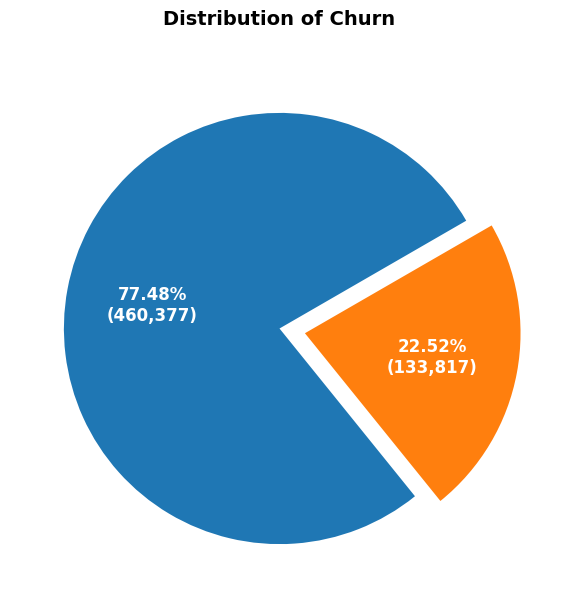

In [11]:
counts = training_data['Churn'].value_counts().sort_index()
labels = ['Yes', 'No']

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, autopct=lambda pct: f'{pct:.2f}%\n({int(pct/100*len(training_data)):,})', startangle=30, textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'}, explode=(0, 0.12))

plt.title("Distribution of Churn", fontsize=14, fontweight='bold', pad=25)
plt.show()

#### Train-Test Distribution Drift

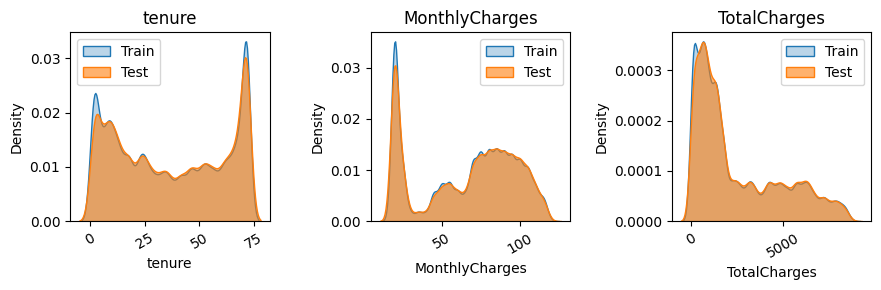

In [12]:
num_cols = 3
num_features = len(numerical_features)
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(3 * num_cols, 3 * num_rows)
)
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.kdeplot(training_data[col], ax=axes[i], label='Train', fill=True, alpha=0.3)
    sns.kdeplot(test_data[col], ax=axes[i], label='Test', fill=True, alpha=0.6)
    axes[i].set_title(f'{col}')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Distribution of Numerical Features 

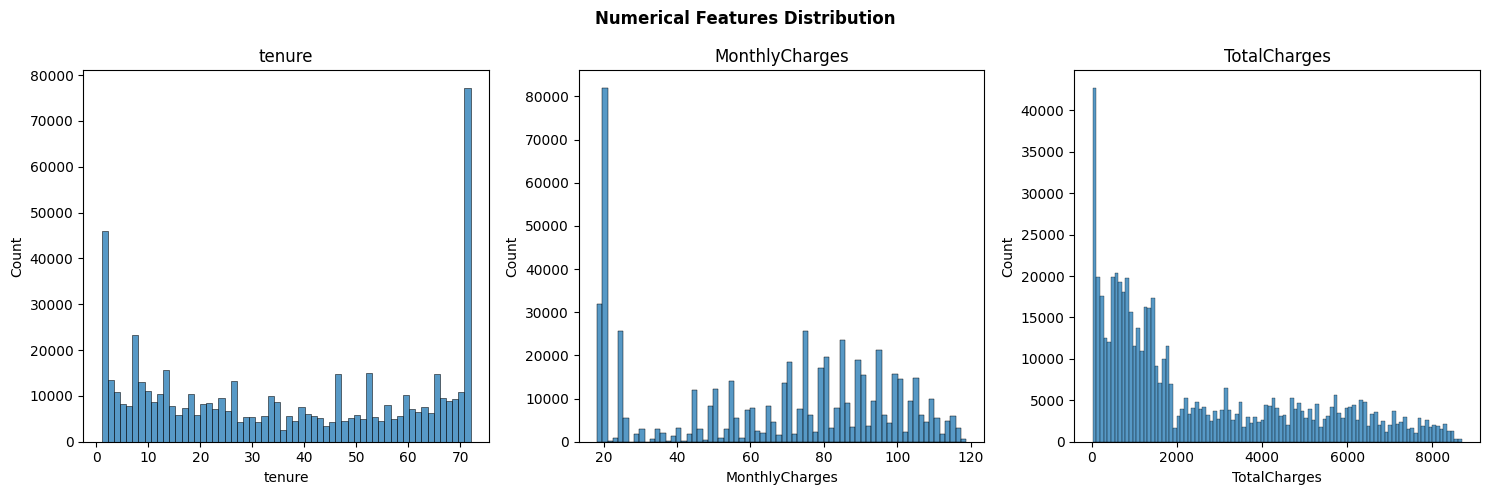

In [13]:
num_cols = 3
num_features = len(numerical_features)
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))

axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.histplot(training_data[col], ax=axes[i])
    axes[i].set_title(f'{col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Numerical Features Distribution", fontweight='bold')
plt.tight_layout()
plt.show()

#### Distribution of Categorical Features

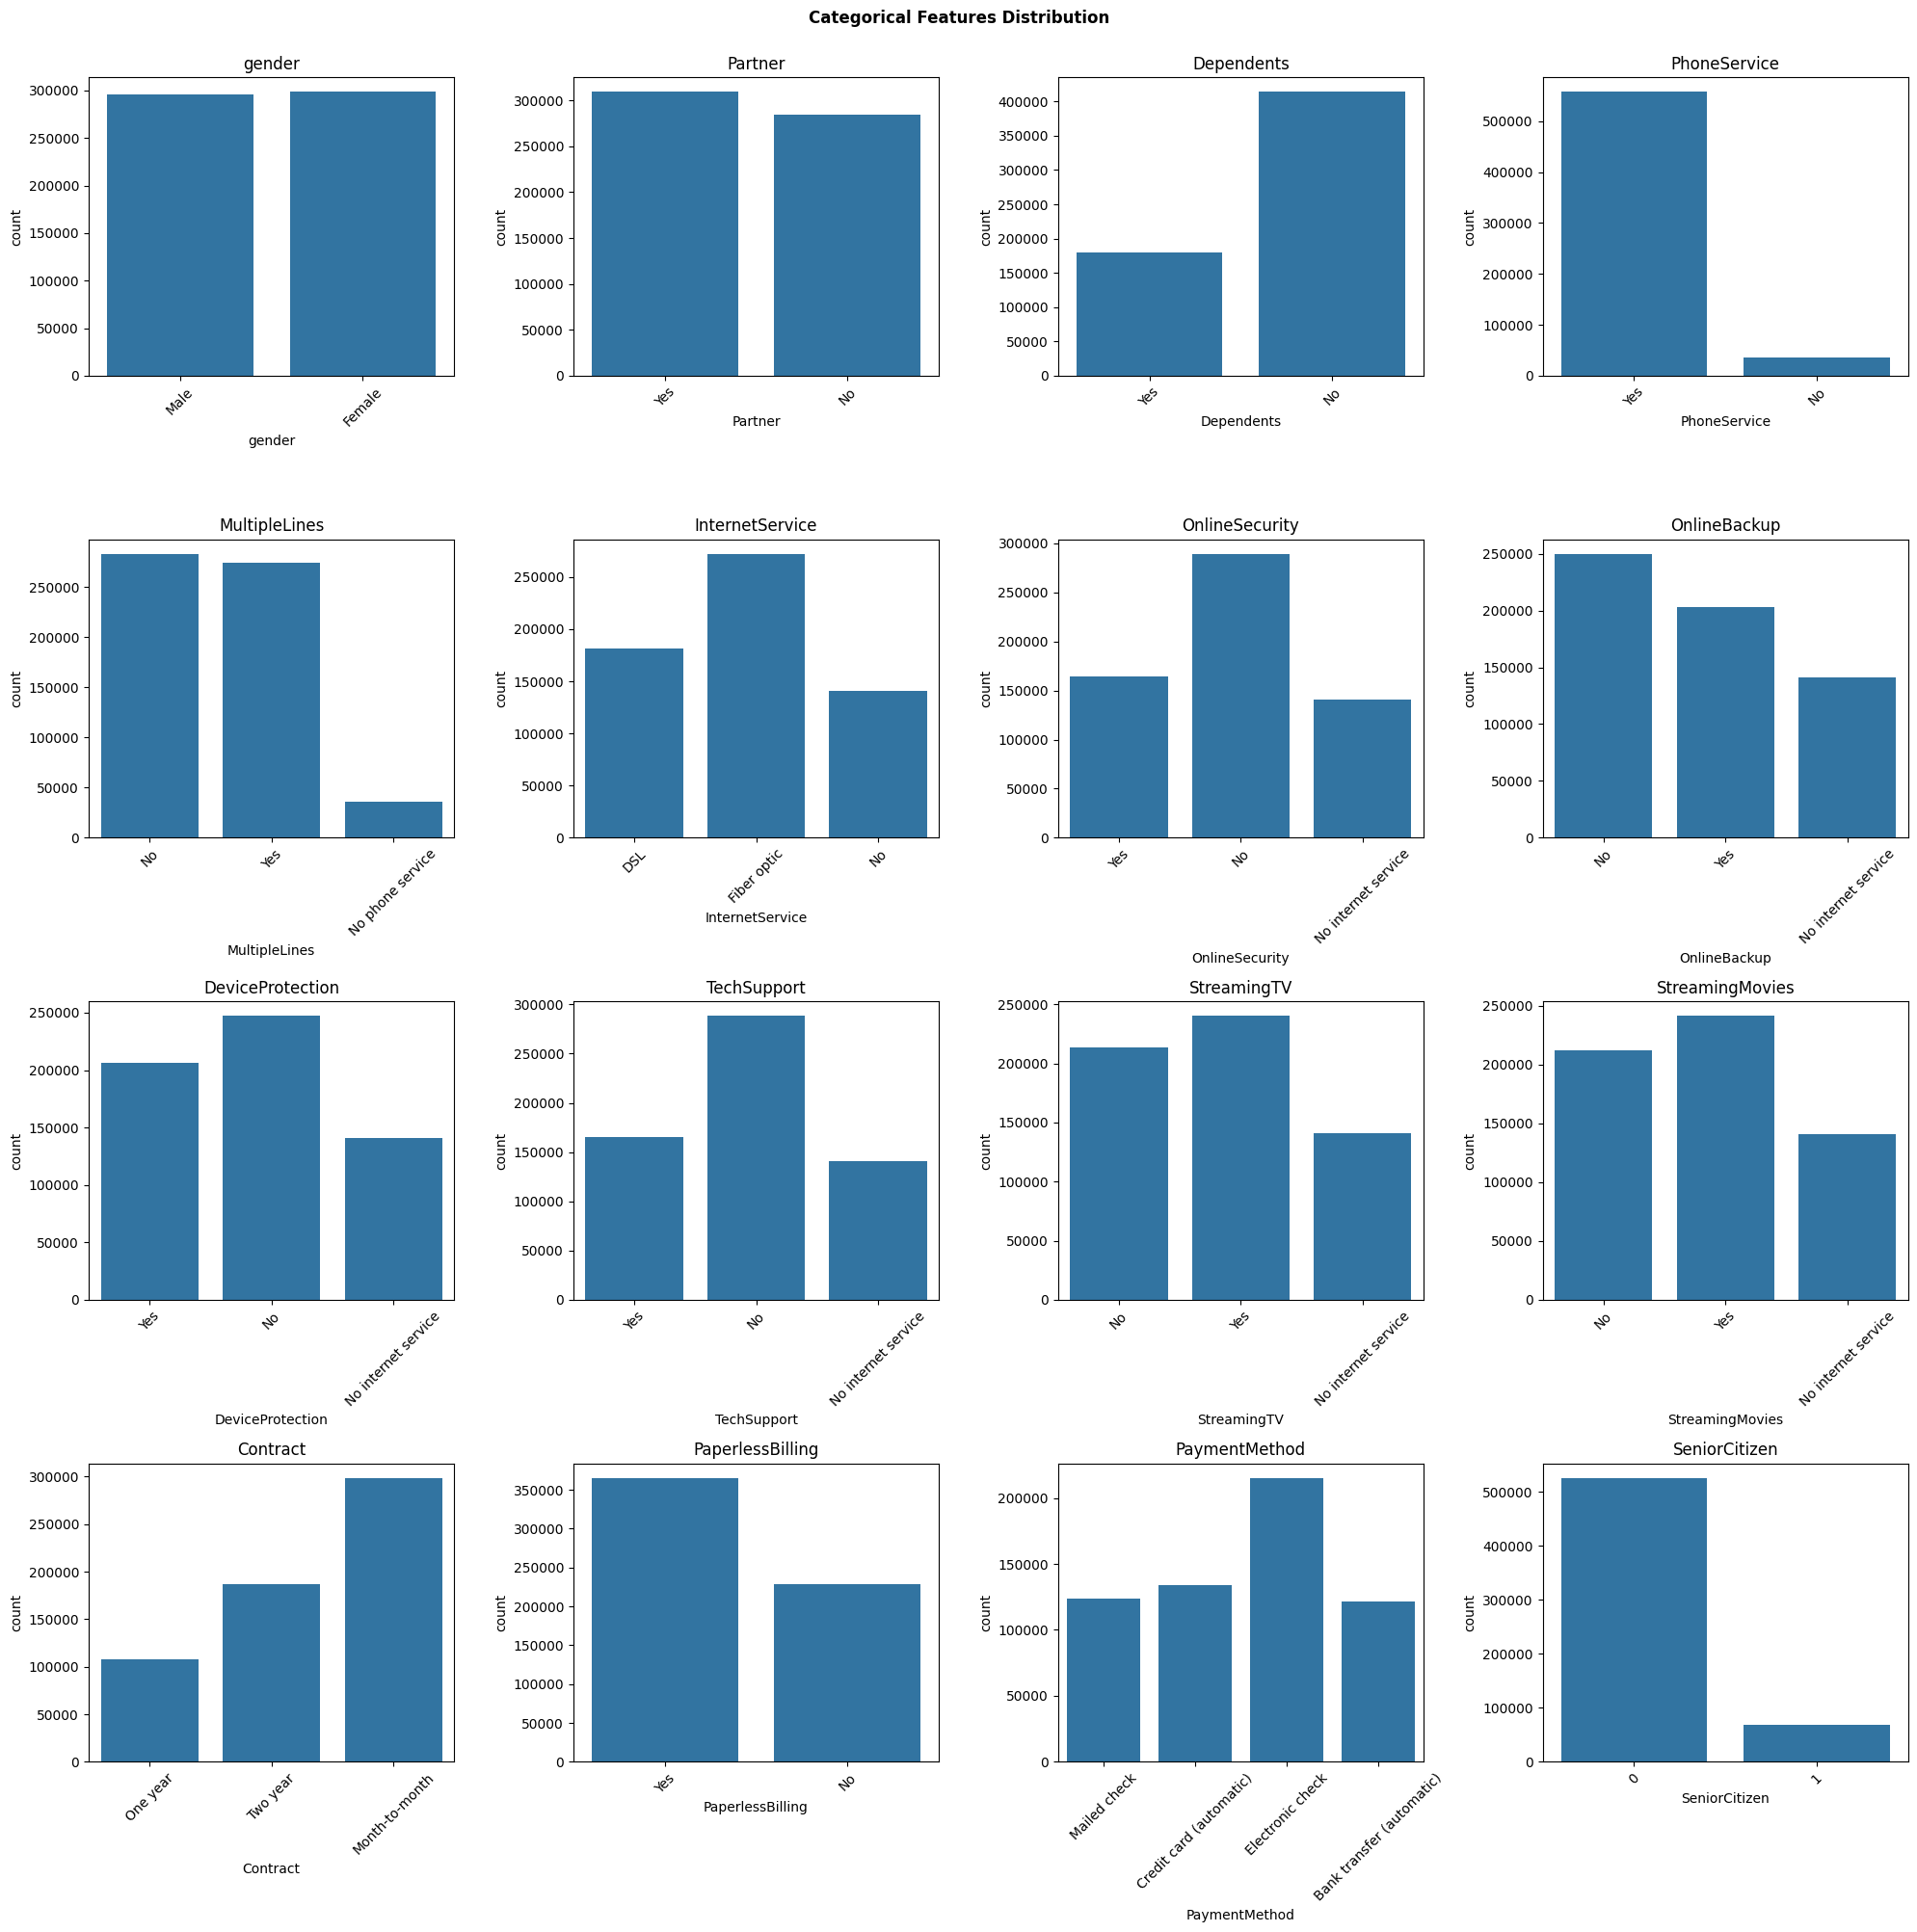

In [14]:
num_cols = 4
num_features = len(categorical_features)
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols,figsize=(5 * num_cols, 5 * num_rows))

axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(data=training_data, x=col, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Categorical Features Distribution", y=1, fontweight='bold')
plt.tight_layout()
plt.show()

#### Outlier Analysis

In [15]:
for col in numerical_features:
    Q1 = training_data[col].quantile(0.25)
    Q3 = training_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}: Lower bound = {lower_bound:.2f}, Upper bound = {upper_bound:.2f}")

    outliers = training_data[(training_data[col] < lower_bound) | (training_data[col] > upper_bound)]
    print(f"Number of outliers in {col}: {outliers.shape[0]}\n")

tenure: Lower bound = -63.00, Upper bound = 137.00
Number of outliers in tenure: 0

MonthlyCharges: Lower bound = -61.45, Upper bound = 182.15
Number of outliers in MonthlyCharges: 0

TotalCharges: Lower bound = -4796.58, Upper bound = 9700.03
Number of outliers in TotalCharges: 0



### Multivariate EDA

#### Numerical Features Distribution by Target Variable (Churn)

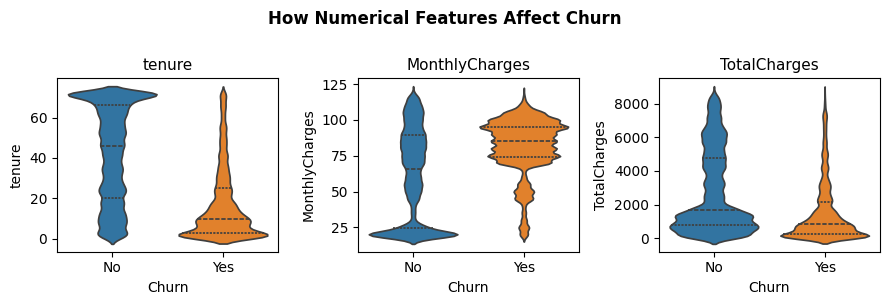

In [16]:
num_cols = 3
num_rows = math.ceil(len(numerical_features) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(3 * num_cols, 3 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    if training_data[col].nunique() <= 1:
        axes[i].text(0.5, 0.5, f'{col}\n(Constant)', ha='center', va='center', 
                    transform=axes[i].transAxes, fontsize=12)
        axes[i].set_title(f'{col} (No Variance)')
        continue

    sns.violinplot(data=training_data, x=training_data['Churn'], y=col, ax=axes[i], inner='quart', hue=training_data['Churn'], legend=False)
    axes[i].set_title(col, fontsize=11)

for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("How Numerical Features Affect Churn", y=1, fontweight='bold')
plt.tight_layout()
plt.show()

#### Categorical Variable Distribution by Target Variable (Churn)

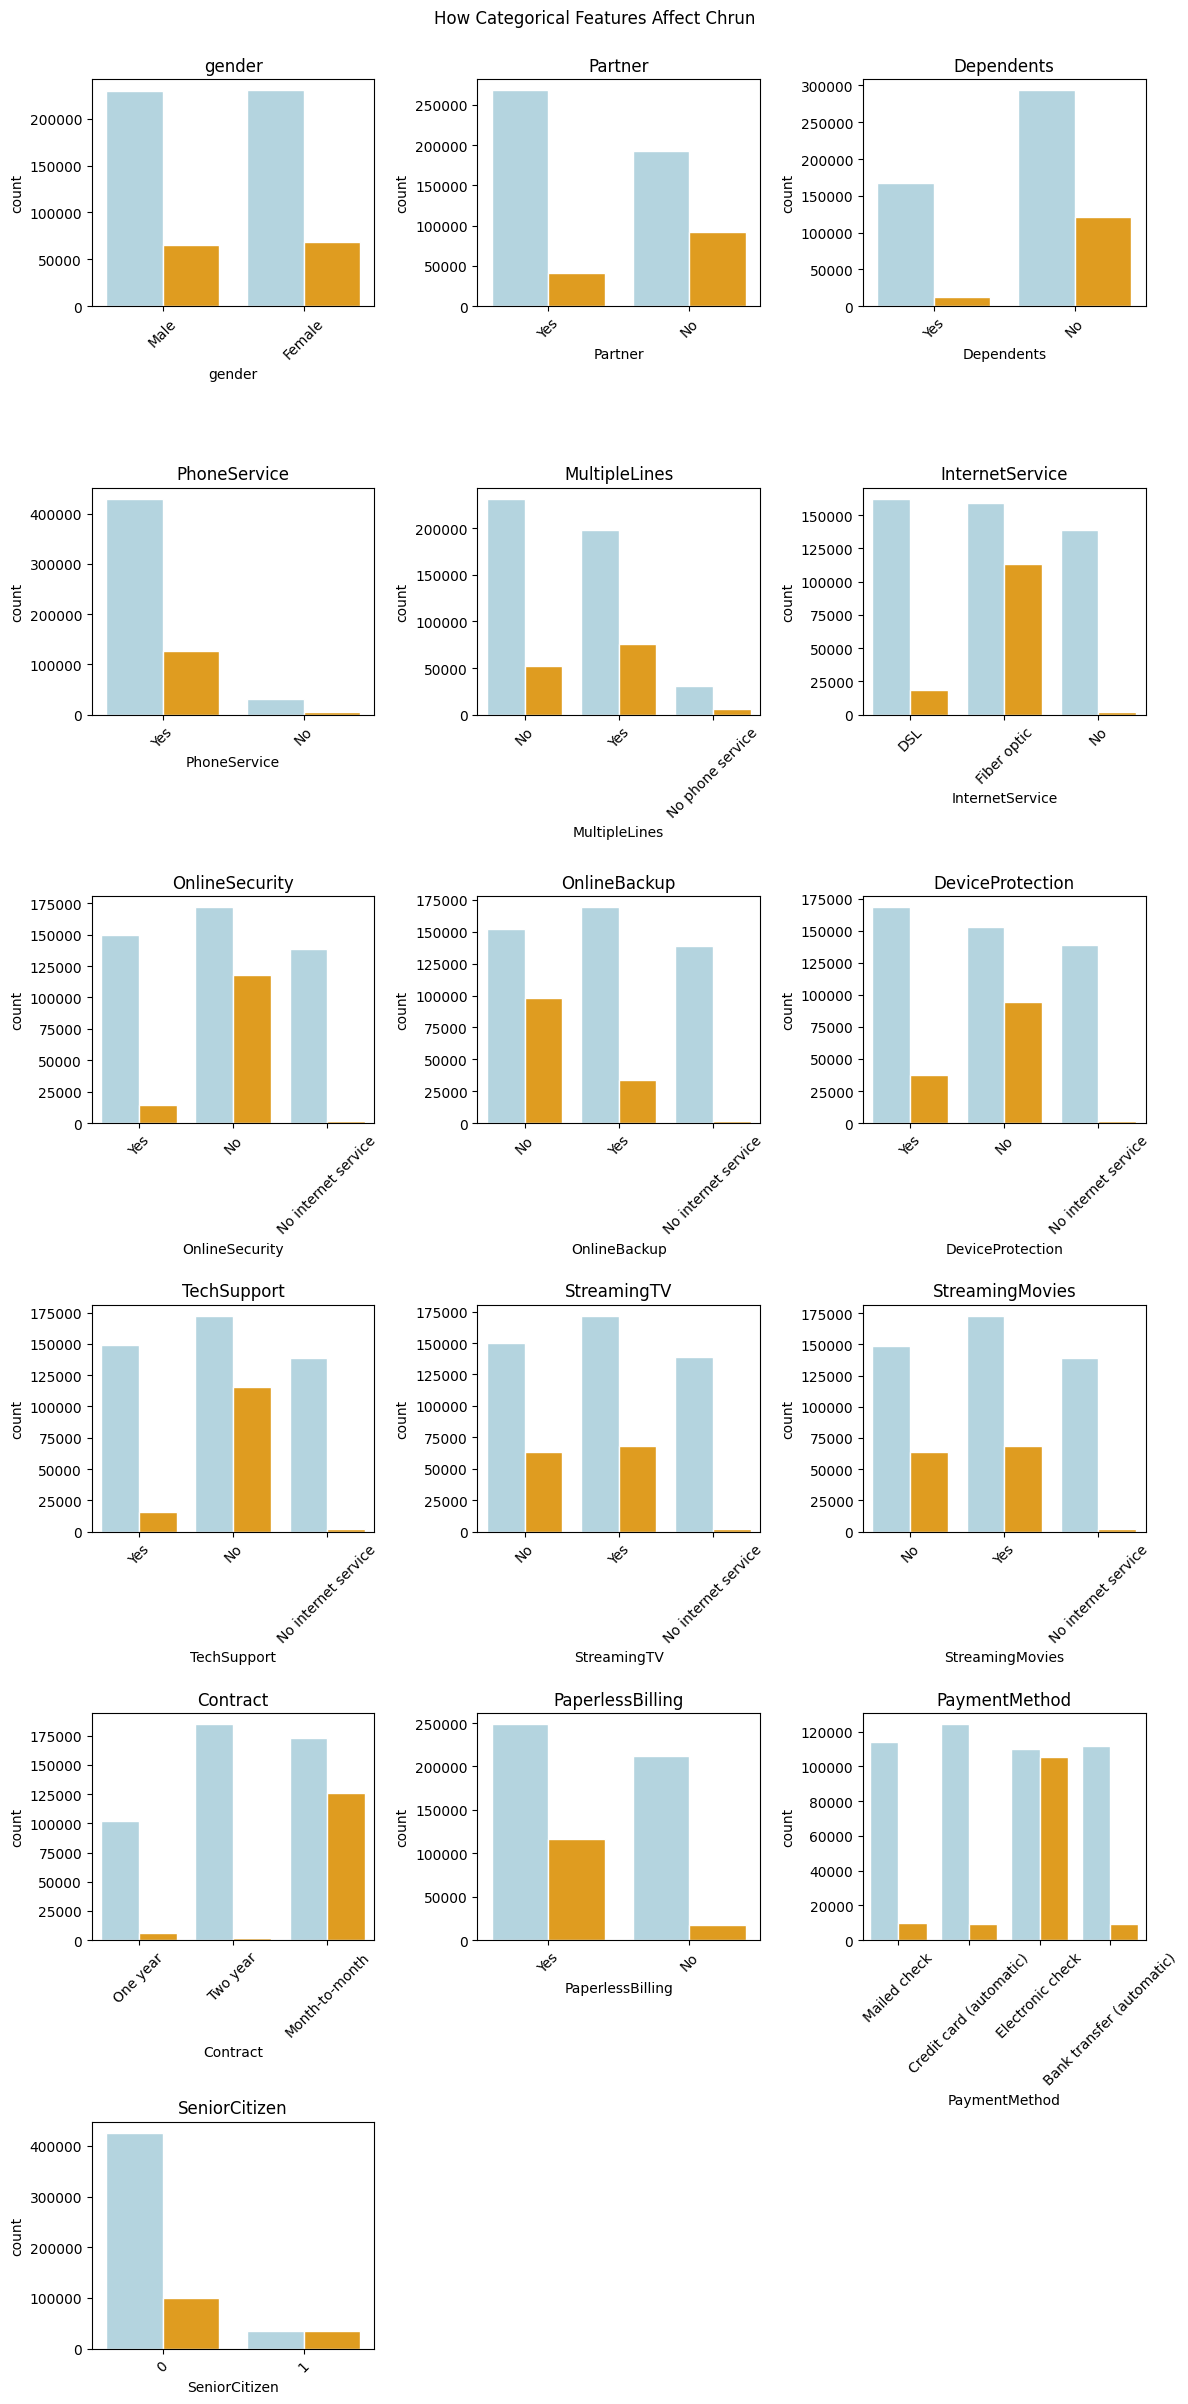

In [17]:
num_cols = 3
num_features = len(categorical_features)
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols,figsize=(4 * num_cols, 4 * num_rows))

axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(data=training_data, x=col, ax=axes[i], hue=training_data['Churn'], edgecolor='white', palette=['lightblue','orange'], legend=False)
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("How Categorical Features Affect Chrun", y=1)
plt.tight_layout()
plt.show()

#### Pearson Feature Correlation Matrix

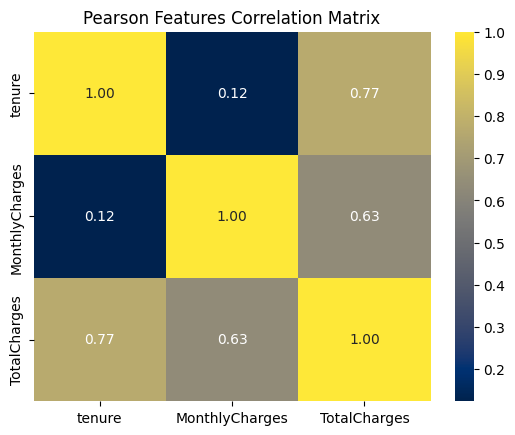

In [18]:
plt.title("Pearson Features Correlation Matrix")
sns.heatmap(training_data[numerical_features].corr(), annot=True, fmt='.2f', cmap='cividis')
plt.show()

#### Cramér's V Correlation Heatmap

In [19]:
def cramer_v(a, b):
    confusion_matrix = pd.crosstab(a, b)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    r,k = confusion_matrix.shape
    phi2 = chi2/n
    phi2corr = max(0,phi2-((k-1)*(r-1))/(n-1))
    rcorr = r - ((r - 1) ** 2) / ( n - 1 )
    kcorr = k - ((k - 1) ** 2) / ( n - 1 )

    if min((kcorr - 1),(rcorr - 1)) == 0:
        return 0
    else:
        return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

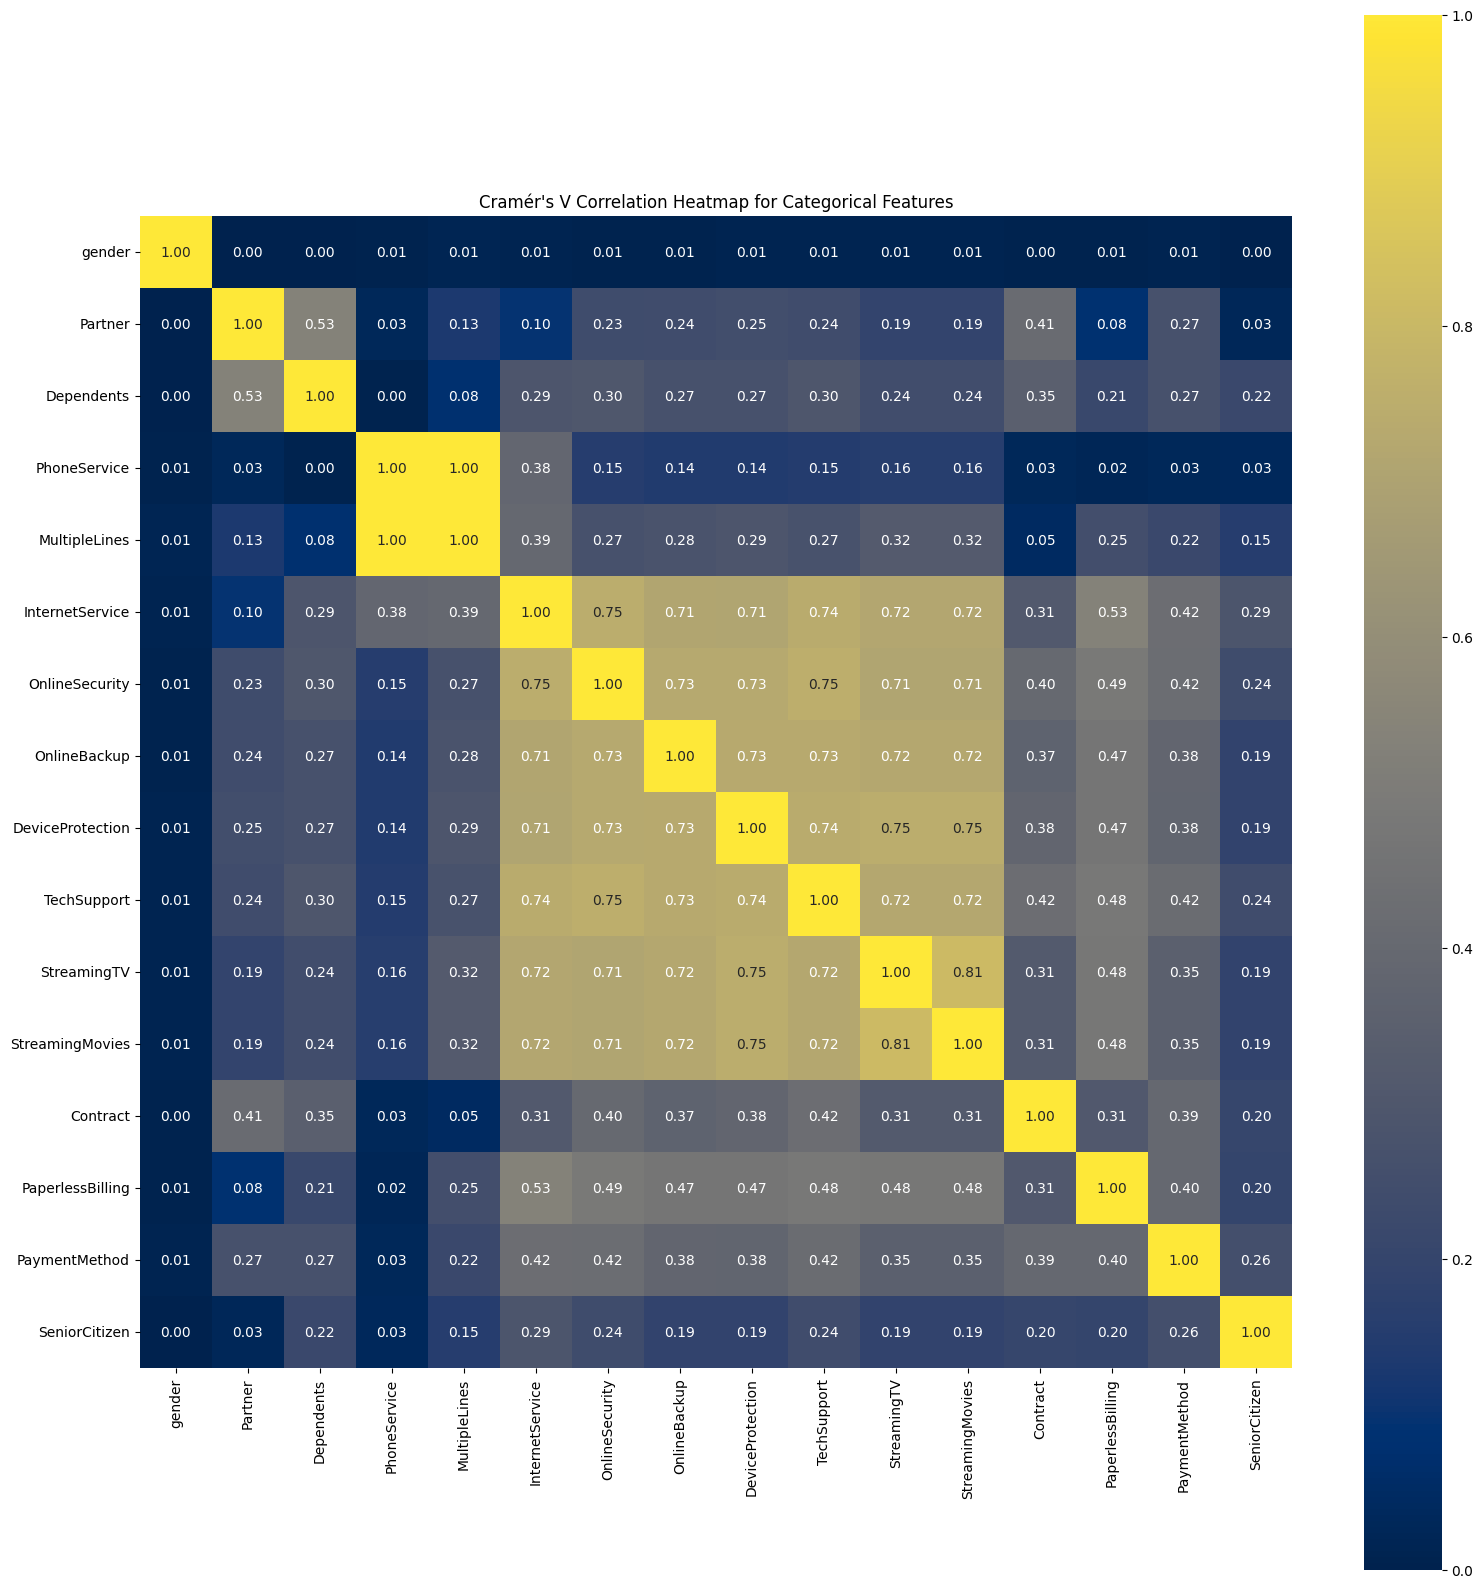

In [20]:
m = len(categorical_features)
corr_matrix = np.zeros((m, m))
for i, col1 in enumerate(categorical_features):
    for j, col2 in enumerate(categorical_features):
        if i == j:
            corr_matrix[i, j] = 1.0
        else:
            corr_matrix[i, j] = cramer_v(training_data[col1], training_data[col2])
            corr_matrix[j, i] = corr_matrix[i, j]

corr_df = pd.DataFrame(corr_matrix, index=categorical_features, columns=categorical_features)

plt.figure(figsize=(16, 16))
sns.heatmap(corr_df, annot=True, square=True, fmt='.2f', cmap='cividis')
plt.title("Cramér's V Correlation Heatmap for Categorical Features")
plt.tight_layout()
plt.show()


#### Correlation Analysis of Churn with Categorical Features

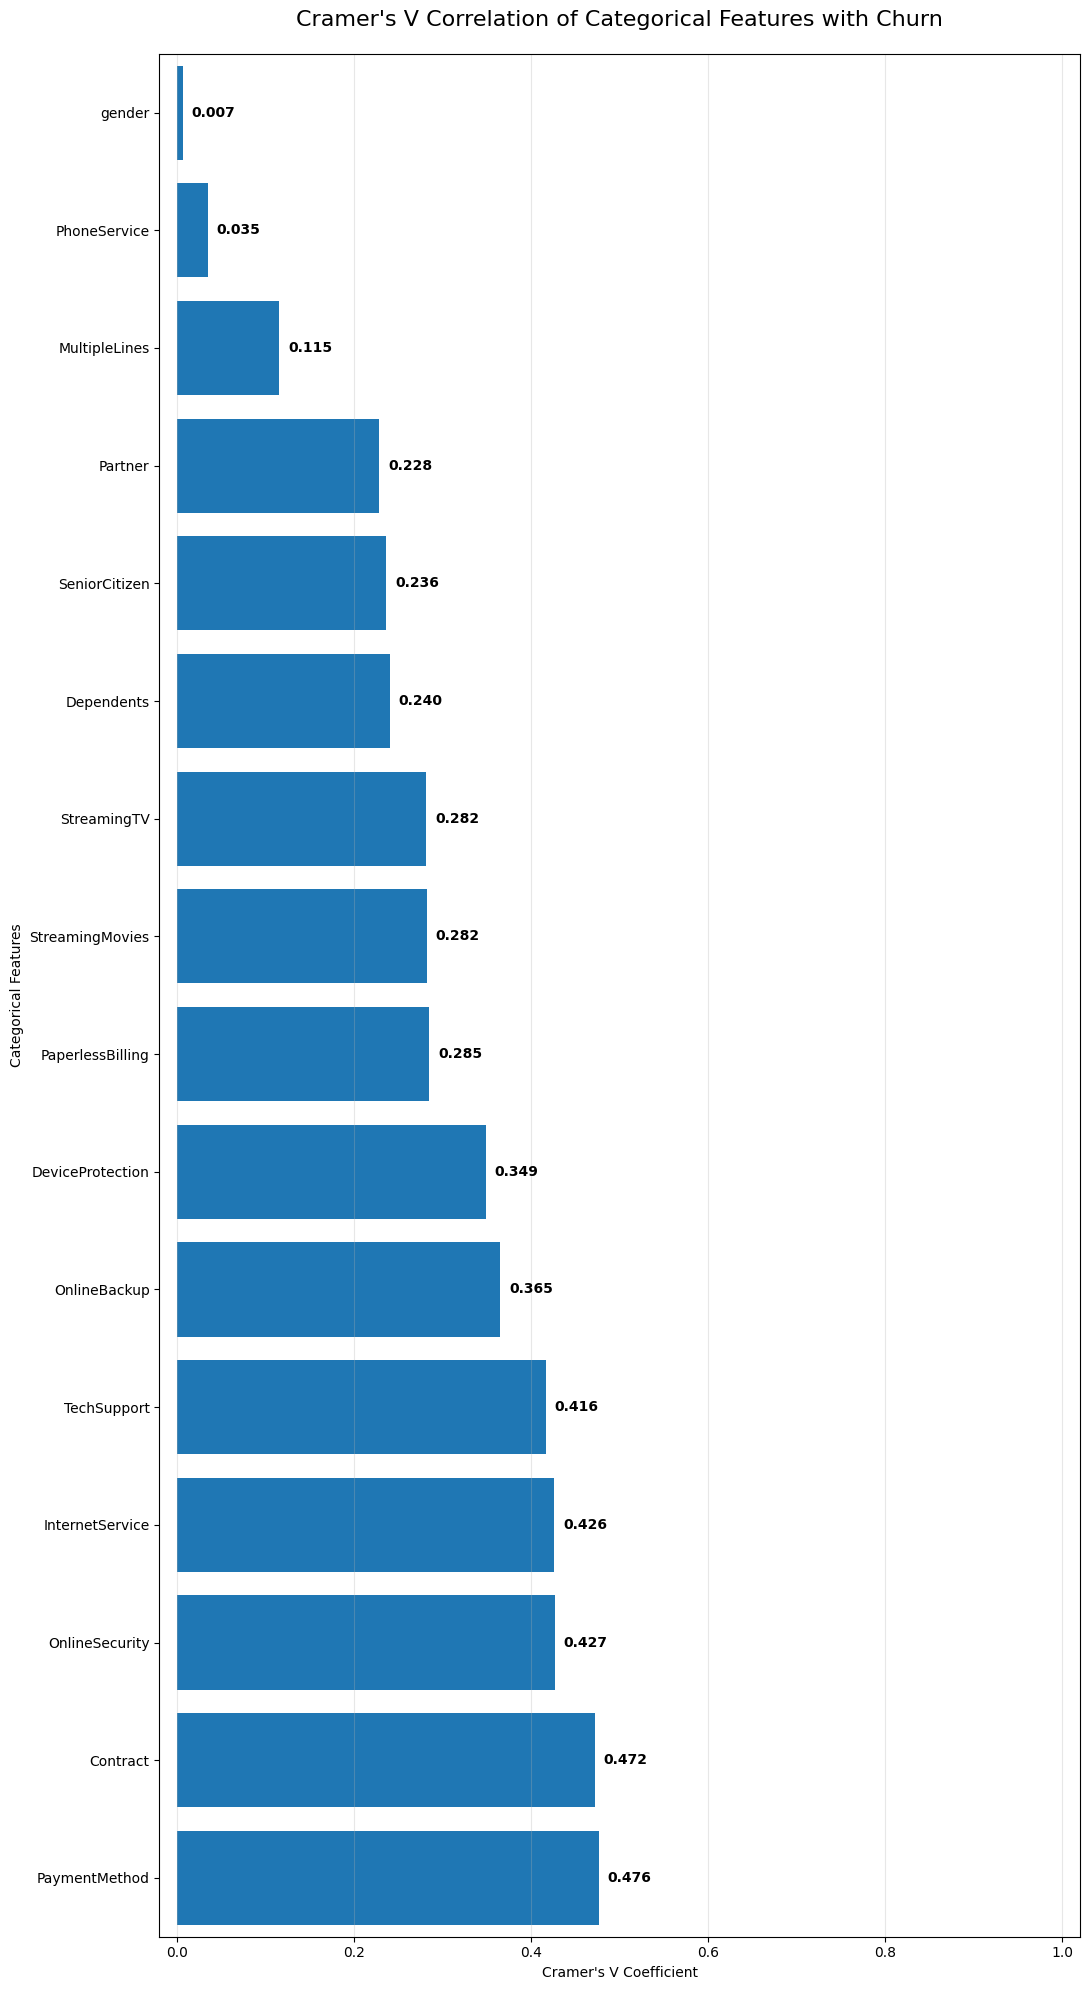

In [21]:
cramers_corr = pd.Series(dtype=float)
for feature in categorical_features:
    if feature != 'Churn':
        cramers_corr[feature] = cramer_v(training_data[feature], training_data['Churn'])

cramers_corr = cramers_corr.sort_values(key=abs, ascending=False)

plt.figure(figsize=(11, max(20, len(cramers_corr) * 0.6)))
colors = ['gray' if x < 0 else '#3F0047' for x in cramers_corr.values]
bars = plt.barh(cramers_corr.index, cramers_corr.values)

for i, (bar, val) in enumerate(zip(bars, cramers_corr.values)):
    plt.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', ha='left' if val >= 0 else 'right', va='center', fontweight='bold')

plt.yticks(range(len(cramers_corr)), cramers_corr.index, fontsize=10)
plt.ylim(-0.5, len(cramers_corr) - 0.5)
plt.xlim(-0.02, 1.02)

plt.title("Cramer's V Correlation of Categorical Features with Churn", fontsize=16, pad=20)
plt.xlabel("Cramer\'s V Coefficient")
plt.ylabel('Categorical Features')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Engineering

In [22]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

In [23]:
training_data['Churn'] = training_data['Churn'].map({'Yes': 1, 'No': 0})

In [24]:
X = training_data.drop(columns=['Churn'])
y = training_data['Churn']


In [25]:
base_features = (training_data.select_dtypes('object').columns.to_list()) + ['SeniorCitizen', 'tenure']

In [26]:
base_features_index = [training_data.columns.get_loc(col) for col in base_features]

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [28]:
valid_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_data))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.05,
        depth=6,
        eval_metric='AUC',
        random_seed=42,
        early_stopping_rounds=100,
        verbose=200
    )
    
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=base_features_index,
        use_best_model=True
    )
    
    # Validation predictions
    val_preds = model.predict_proba(X_val)[:, 1]
    valid_preds[val_idx] = val_preds
    
    # Test predictions
    test_preds += model.predict_proba(test_data)[:, 1] / skf.n_splits

Fold 1
0:	test: 0.8944303	best: 0.8944303 (0)	total: 767ms	remaining: 25m 32s
200:	test: 0.9133848	best: 0.9133850 (199)	total: 1m 46s	remaining: 15m 55s
400:	test: 0.9145881	best: 0.9145881 (400)	total: 3m 41s	remaining: 14m 44s
600:	test: 0.9151742	best: 0.9151742 (600)	total: 5m 37s	remaining: 13m 6s
800:	test: 0.9154500	best: 0.9154500 (800)	total: 7m 35s	remaining: 11m 21s
1000:	test: 0.9156157	best: 0.9156187 (997)	total: 9m 33s	remaining: 9m 31s
1200:	test: 0.9157321	best: 0.9157321 (1200)	total: 11m 31s	remaining: 7m 39s
1400:	test: 0.9157873	best: 0.9157873 (1400)	total: 13m 30s	remaining: 5m 46s
1600:	test: 0.9158556	best: 0.9158556 (1599)	total: 15m 31s	remaining: 3m 52s
1800:	test: 0.9158862	best: 0.9158910 (1772)	total: 17m 31s	remaining: 1m 56s
1999:	test: 0.9159059	best: 0.9159063 (1995)	total: 19m 31s	remaining: 0us

bestTest = 0.9159063105
bestIteration = 1995

Shrink model to first 1996 iterations.
Fold 2
0:	test: 0.8958228	best: 0.8958228 (0)	total: 690ms	remaining: 

In [29]:
auc_score = roc_auc_score(y, valid_preds)
print("Overall AUC:", auc_score)

Overall AUC: 0.9162306782164316


In [30]:
final_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=200
)

final_model.fit(
    X, y,
    cat_features=base_features_index
)

0:	total: 730ms	remaining: 24m 19s
200:	total: 2m 3s	remaining: 18m 23s
400:	total: 4m 14s	remaining: 16m 56s
600:	total: 6m 31s	remaining: 15m 12s
800:	total: 8m 51s	remaining: 13m 16s
1000:	total: 11m 8s	remaining: 11m 7s
1200:	total: 13m 24s	remaining: 8m 55s
1400:	total: 15m 41s	remaining: 6m 42s
1600:	total: 17m 58s	remaining: 4m 28s
1800:	total: 20m 16s	remaining: 2m 14s
1999:	total: 22m 33s	remaining: 0us


In [31]:
final_test_preds = final_model.predict_proba(test_data)[:, 1]

In [32]:
submission = pd.DataFrame({
    "id": test_data.index,  
    "Churn": final_test_preds
})

submission.to_csv("submission.csv", index=False)